In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('17-cardekho.csv')
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [4]:
df = df.drop('Unnamed: 0',axis = 1)

df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.5 MB


In [6]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [7]:
#Göründüyü kimi bir çox columnda problem yoxdur ancaq seats də min 0 var onu araşdıraq
df['seats'].value_counts()

seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64

In [8]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [9]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
197,Honda City,Honda,City,8,70000,Individual,Petrol,Manual,16.80,1497,116.30,5,545000
360,Maruti Baleno,Maruti,Baleno,2,5000,Individual,Petrol,Automatic,21.40,1197,83.10,5,686000
1353,Maruti Swift Dzire,Maruti,Swift Dzire,4,50000,Individual,Diesel,Manual,28.40,1248,74.02,5,680000
1429,Maruti Wagon R,Maruti,Wagon R,13,100000,Individual,Petrol,Manual,18.90,1061,67.00,5,150000
1485,Hyundai i20,Hyundai,i20,3,50000,Individual,Petrol,Manual,18.60,1197,81.83,5,625000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15229,Maruti Swift,Maruti,Swift,8,80000,Individual,Diesel,Manual,22.90,1248,74.00,5,350000
15324,Maruti Wagon R,Maruti,Wagon R,6,50000,Individual,CNG,Manual,26.60,998,58.16,5,450000
15367,Tata Tiago,Tata,Tiago,4,30000,Individual,Petrol,Manual,23.84,1199,84.00,5,350000
15378,Hyundai Grand,Hyundai,Grand,6,30000,Individual,Petrol,Manual,18.90,1197,82.00,5,450000


ignore_index=False (Default): Dublikat sətirlər silinir, amma qalan sətirlər öz orijinal indekslərini saxlayırlar. Nəticədə indeks ardıcıllığında "deşiklər" yaranır (məsələn: 0, 1, 3, 5...).

ignore_index=True: Dublikatlar silindikdən sonra Pandas bütün indeksləri silir və sıfırdan başlayaraq (0, 1, 2, 3...) yeni, ardıcıl bir indeks təyin edir.

keep parametri isə duplicatedlərdən birinci duplicatı saxlayır digərlərim silir


In [10]:
df = df.drop_duplicates(keep = "first",ignore_index=True)


In [12]:
df[df.duplicated()]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [13]:
#seatsi 0 olanlari 5 ile evez edek

df[df['seats'] == 0]

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
3207,Honda City,Honda,City,18,40000,Individual,Petrol,Manual,13.00,1493,100.00,0,115000
12504,Nissan Kicks,Nissan,Kicks,2,10000,Individual,Diesel,Manual,19.39,1461,108.49,0,1154000


In [14]:
df.loc[df["seats"] == 0,"seats"] = 5

In [15]:
df['seats'].value_counts()

seats
5    12769
7     1902
8      310
6      125
4       76
9       55
2        7
Name: count, dtype: int64

In [16]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.000000,1.524400e+04,15244.000000,15244.000000,15244.000000,15244.000000,1.524400e+04
mean,6.041131,5.563958e+04,19.697333,1486.171543,100.607652,5.326817,7.747014e+05
std,3.016228,5.176630e+04,4.169307,520.419390,42.915687,0.806464,8.946761e+05
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,2.000000,4.000000e+04
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.590000e+05
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [17]:
#float deyerlerin daha duzgun gosterilmesi
pd.set_option('display.float_format','{:.2f}'.format)

In [18]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00,15244.00
mean,6.04,55639.58,19.70,1486.17,100.61,5.33,774701.45
std,3.02,51766.30,4.17,520.42,42.92,0.81,894676.08
min,0.00,100.00,4.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,559000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,6592.00,626.00,9.00,39500000.00


In [19]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


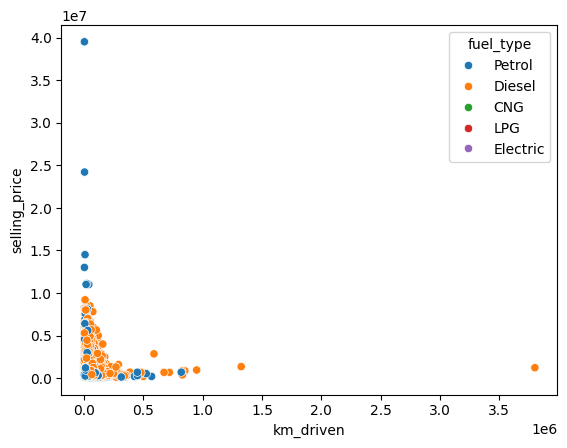

In [21]:
#Avtomobilin km məsafəsi ilə satış qiyməti arasındakı əlaqə hue = fuel_type

sns.scatterplot(x = df['km_driven'],y =df['selling_price'],hue = df['fuel_type'] )
plt.show()


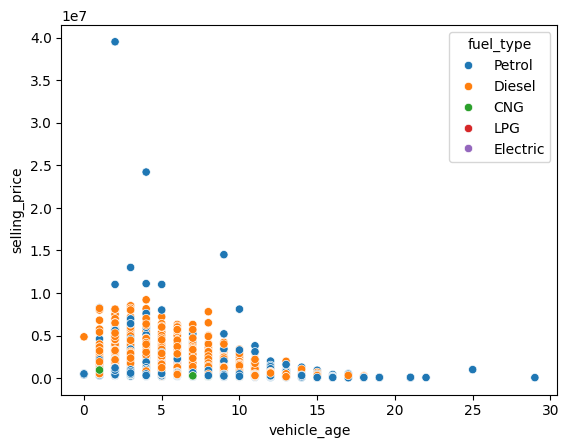

In [22]:
#Avtomobilin yaşı ilə satış qiyməti arasındakı əlaqə hue = fuel_type

sns.scatterplot(x = df['vehicle_age'],y =df['selling_price'],hue = df['fuel_type'] )
plt.show()


In [28]:
#outlierlar var ona gore qiymeti 10 milyondan cox olanlari silmeliyik
df = df[(df['selling_price'] < 10000000)]

In [29]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15237.00,15237.00,15237.00,15237.00,15237.00,15237.00,15237.00
mean,6.04,55658.27,19.70,1484.68,100.43,5.33,766899.58
std,3.02,51770.12,4.16,515.17,42.06,0.81,789564.21
min,0.00,100.00,6.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,557000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,825000.00
max,29.00,3800000.00,33.54,5998.00,600.00,9.00,9200000.00


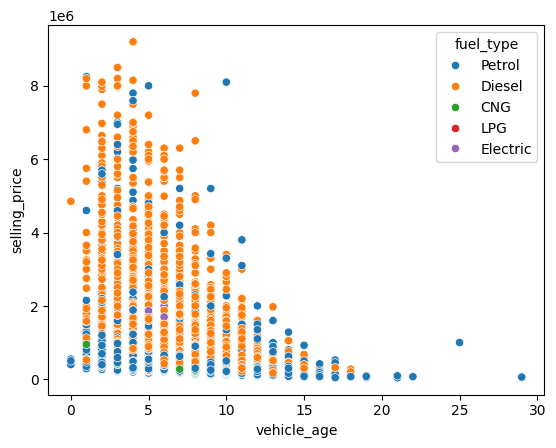

In [30]:
#Hemin qrafiki yeniden cekey

sns.scatterplot(x = df['vehicle_age'],y =df['selling_price'],hue = df['fuel_type'] )
plt.show()


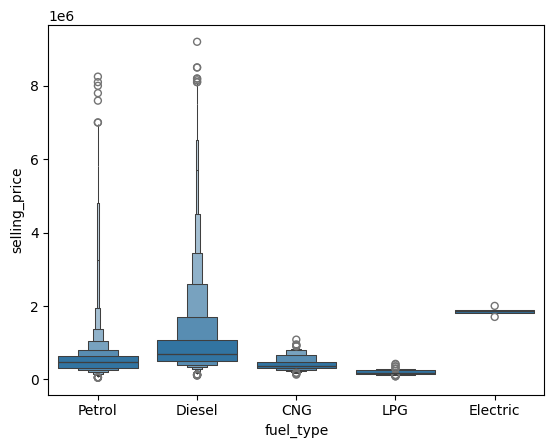

In [31]:
sns.boxenplot(data = df,x='fuel_type',y = 'selling_price')

plt.show()

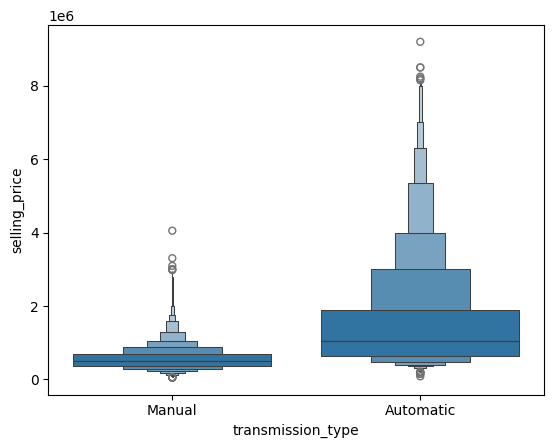

In [32]:
#Manuel ve avtomata görə qiymətin paylanması
sns.boxenplot(data = df,x='transmission_type',y = 'selling_price')

plt.show()

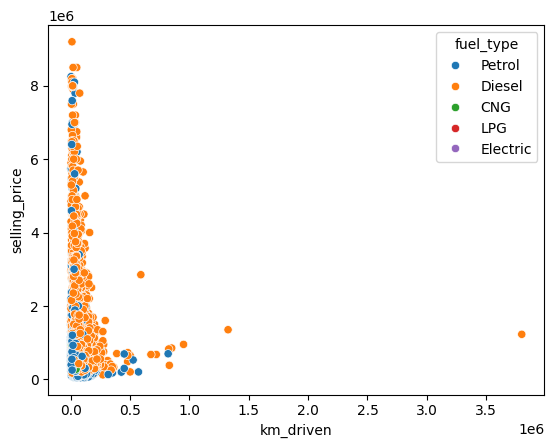

In [33]:
sns.scatterplot(x = df['km_driven'],y =df['selling_price'],hue = df['fuel_type'] )
plt.show()

In [34]:
#gorunduyu kimi km_dirvendede outlier var onuda silek

In [35]:
df.km_driven.max()

np.int64(3800000)

In [36]:
df = df[(df['km_driven'] < 1000000)]

In [37]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15235.00,15235.00,15235.00,15235.00,15235.00,15235.00,15235.00
mean,6.04,55329.18,19.70,1484.53,100.42,5.33,766831.24
std,3.02,40673.18,4.16,515.03,42.05,0.81,789593.18
min,0.00,100.00,6.00,793.00,38.40,2.00,40000.00
25%,4.00,30000.00,17.00,1197.00,74.00,5.00,385000.00
50%,6.00,50000.00,19.67,1248.00,88.50,5.00,557000.00
75%,8.00,70000.00,22.70,1582.00,117.30,5.00,823500.00
max,29.00,950000.00,33.54,5998.00,600.00,9.00,9200000.00


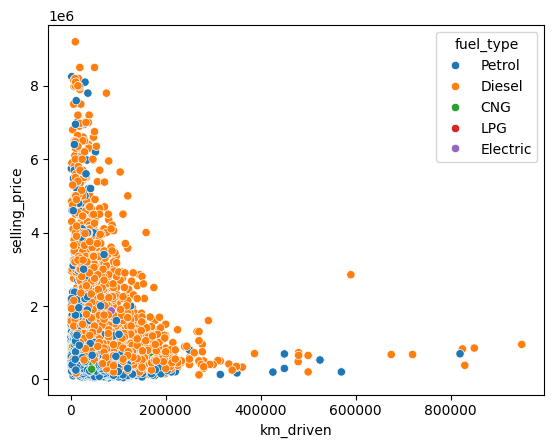

In [38]:
sns.scatterplot(x = df['km_driven'],y =df['selling_price'],hue = df['fuel_type'] )
plt.show()

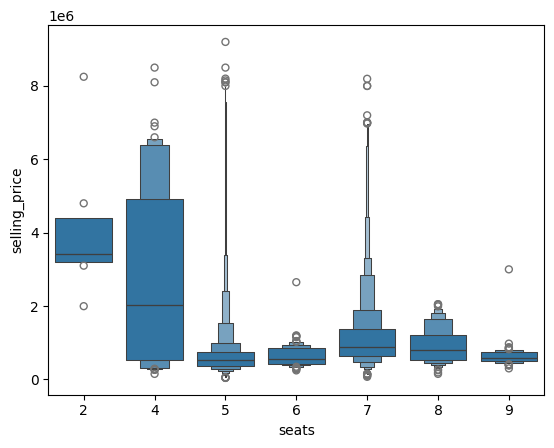

In [39]:
#oturacaq sayına görə qiymətin paylanması
sns.boxenplot(data = df,x='seats',y = 'selling_price')

plt.show()

In [40]:
df.corr(numeric_only=True)

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
vehicle_age,1.00,0.42,-0.26,0.10,0.01,0.03,-0.27
km_driven,0.42,1.00,-0.13,0.24,0.05,0.23,-0.11
mileage,-0.26,-0.13,1.00,-0.63,-0.53,-0.44,-0.32
engine,0.10,0.24,-0.63,1.00,0.80,0.56,0.61
max_power,0.01,0.05,-0.53,0.80,1.00,0.18,0.77
seats,0.03,0.23,-0.44,0.56,0.18,1.00,0.14
selling_price,-0.27,-0.11,-0.32,0.61,0.77,0.14,1.00


In [41]:
#Asli ve musteqil deyisenleri ayiraq

In [42]:
X = df.drop('selling_price',axis = 1)
y = df['selling_price']

In [43]:
X.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5


In [44]:
from  sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [45]:
cat_cols = df.select_dtypes("str").columns.to_list()
cat_cols

['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

In [46]:
unique_values = df[cat_cols].nunique()

In [47]:
unique_values 

car_name             119
brand                 30
model                118
seller_type            3
fuel_type              5
transmission_type      2
dtype: int64

In [48]:
#seller_type,fuel_type,transmission_type - >one hot encoding
#car_name,brand,model ->frequency encoding

In [51]:
one_hot_columns = ['seller_type','fuel_type','transmission_type']
freq_columns = ['car_name','brand','model']
X_train['car_name'].value_counts() / len(X_train)

car_name
Hyundai i20             0.06
Maruti Swift Dzire      0.06
Maruti Alto             0.05
Maruti Swift            0.05
Honda City              0.05
                        ... 
Kia Carnival            0.00
Bentley Continental     0.00
Maruti Dzire LXI        0.00
Maserati Quattroporte   0.00
Maserati Ghibli         0.00
Name: count, Length: 115, dtype: float64

In [52]:
for col in freq_columns:
    freq = X_train[col].value_counts() / len(X_train)
    X_train[col+'_freq'] = X_train[col].map(freq)

    X_test[col+'_freq'] = X_test[col].map(freq)

    mean_freq = freq.mean()

    X_test[col+'_freq'] = X_test[col+'_freq'].fillna(mean_freq)

    

In [53]:
X_train.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,car_name_freq,brand_freq,model_freq
10447,Honda City,Honda,City,4,45000,Dealer,Petrol,Manual,17.40,1497,117.60,5,0.05,0.10,0.05
14245,Maruti Alto,Maruti,Alto,6,16000,Dealer,Petrol,Automatic,23.95,998,67.05,5,0.05,0.32,0.05
5333,Honda Amaze,Honda,Amaze,4,60000,Dealer,Diesel,Manual,25.80,1498,98.60,5,0.02,0.10,0.02
2937,Mercedes-Benz E-Class,Mercedes-Benz,E-Class,7,40000,Individual,Diesel,Automatic,13.00,2143,204.00,5,0.01,0.02,0.01
6419,Maruti Baleno,Maruti,Baleno,4,32000,Dealer,Petrol,Manual,21.01,1197,81.80,5,0.02,0.32,0.02


In [54]:
X_train = X_train.drop(["car_name","brand","model"],axis = 1)

X_test = X_test.drop(["car_name","brand","model"],axis = 1)

In [55]:
#one hot encoding

In [56]:
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose  import ColumnTransformer

ColumnTransformer, məlumat dəstindəki (dataset) hər sütuna fərqli əməliyyatları eyni anda tətbiq etməyə imkan verən bir "idarəetmə mərkəzi"dir.

Maşın öyrənməsində bəzi sütunlar kateqorikdir (məsələn, Şəhər), bəziləri rəqəmsaldır (məsələn, Qiymət). Sən hamısına eyni şeyi tətbiq edə bilməzsən. ColumnTransformer sayəsində sən deyirsən: "Bu 3 sütunu OneHot edək, bu 2 sütunu Scale edək, qalanlarına isə toxunmayaq."

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ColumnTransformer Parametrləri Cheat Sheet
transformer = ColumnTransformer(
    # 1. transformers: Ən vacib parametr. Bu bir siyahıdır (list).
    # Hər bir element bir "tuple"dur: (Ad, Hansı Transformasiya, Hansı Sütunlar)
    transformers=[
        (
            "onehot",                 # Transformasiyanın adı (istənilən ad)
            OneHotEncoder(            # Tətbiq olunacaq obyekt
                drop="first",         # Multikolliniarlığı önləmək üçün ilk sütunu atır
                handle_unknown="ignore" # Test-də yeni kateqoriya görsə xəta verməz
            ),
            ["Gender", "City"]        # Bu əməliyyatın tətbiq olunacağı sütunlar
        ),
        (
            "scaler",                 # İkinci bir əməliyyat adı
            StandardScaler(),         # Rəqəmləri standartlaşdırır
            ["Age", "Salary"]         # Bu sütunlara tətbiq olunur
        )
    ],

    # 2. remainder (Default: "drop")
    # Siyahıda adı çəkilməyən digər sütunlara nə olsun?
    # "drop": Onları silir (Default budur, diqqətli ol!)
    # "passthrough": Onlara toxunmur, olduğu kimi saxlayır
    remainder="passthrough",

    # 3. sparse_threshold (Default: 0.3)
    # Əgər OneHot-dan sonra data çox "seyrək" (sıfırlarla dolu) olsa, 
    # onu yaddaşa qənaət üçün "sparse matrix" kimi qaytarır.
    sparse_threshold=0.3,

    # 4. n_jobs (Default: None)
    # Paralel hesablama. -1 yazsan prosesi sürətləndirər.
    n_jobs=-1,

    # 5. verbose (Default: False)
    # True etsən, hansı transformasiyanın nə qədər vaxt apardığını göstərər.
    verbose=False,

    # 6. verbose_feature_names_out (Default: True)
    # Çıxışda sütun adlarının əvvəlinə transformasiya adını əlavə edir.
    # Məsələn: "onehot__City_Baku"
    verbose_feature_names_out=True
)

In [57]:
transofrmer = ColumnTransformer(
    transformers=[
        ("onehot",OneHotEncoder(drop="first" , handle_unknown="ignore"),one_hot_columns)
    ],remainder="passthrough"
)

In [58]:
X_train = transofrmer.fit_transform(X_train)
X_test = transofrmer.transform(X_test)

In [59]:
encoded_cols = transofrmer.get_feature_names_out()

In [60]:
encoded_cols

array(['onehot__seller_type_Individual',
       'onehot__seller_type_Trustmark Dealer', 'onehot__fuel_type_Diesel',
       'onehot__fuel_type_Electric', 'onehot__fuel_type_LPG',
       'onehot__fuel_type_Petrol', 'onehot__transmission_type_Manual',
       'remainder__vehicle_age', 'remainder__km_driven',
       'remainder__mileage', 'remainder__engine', 'remainder__max_power',
       'remainder__seats', 'remainder__car_name_freq',
       'remainder__brand_freq', 'remainder__model_freq'], dtype=object)

In [61]:
#bunu etdikden sonra nupmy array oldu X_train və X_test işləmək tərəfdən probkem yoxdur ancaq görünüş cəhət bunu düzəldə bilərim

In [63]:
X_train = pd.DataFrame(X_train,columns=encoded_cols)
X_test = pd.DataFrame(X_test, columns=encoded_cols)

In [64]:
X_train.head()

,onehot__seller_type_Individual,onehot__seller_type_Trustmark Dealer,onehot__fuel_type_Diesel,onehot__fuel_type_Electric,onehot__fuel_type_LPG,onehot__fuel_type_Petrol,onehot__transmission_type_Manual,remainder__vehicle_age,remainder__km_driven,remainder__mileage,remainder__engine,remainder__max_power,remainder__seats,remainder__car_name_freq,remainder__brand_freq,remainder__model_freq
0,0.00,0.00,0.00,0.00,0.00,1.00,1.00,4.00,45000.00,17.40,1497.00,117.60,5.00,0.05,0.10,0.05
1,0.00,0.00,0.00,0.00,0.00,1.00,0.00,6.00,16000.00,23.95,998.00,67.05,5.00,0.05,0.32,0.05
2,0.00,0.00,1.00,0.00,0.00,0.00,1.00,4.00,60000.00,25.80,1498.00,98.60,5.00,0.02,0.10,0.02
3,1.00,0.00,1.00,0.00,0.00,0.00,0.00,7.00,40000.00,13.00,2143.00,204.00,5.00,0.01,0.02,0.01
4,0.00,0.00,0.00,0.00,0.00,1.00,1.00,4.00,32000.00,21.01,1197.00,81.80,5.00,0.02,0.32,0.02


In [65]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10664 entries, 0 to 10663
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   onehot__seller_type_Individual        10664 non-null  float64
 1   onehot__seller_type_Trustmark Dealer  10664 non-null  float64
 2   onehot__fuel_type_Diesel              10664 non-null  float64
 3   onehot__fuel_type_Electric            10664 non-null  float64
 4   onehot__fuel_type_LPG                 10664 non-null  float64
 5   onehot__fuel_type_Petrol              10664 non-null  float64
 6   onehot__transmission_type_Manual      10664 non-null  float64
 7   remainder__vehicle_age                10664 non-null  float64
 8   remainder__km_driven                  10664 non-null  float64
 9   remainder__mileage                    10664 non-null  float64
 10  remainder__engine                     10664 non-null  float64
 11  remainder__max_power      

In [66]:
from sklearn.ensemble import AdaBoostRegressor

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import r2_score ,mean_absolute_error,mean_squared_error

from sklearn.model_selection  import RandomizedSearchCV

In [71]:
model = AdaBoostRegressor()

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# AdaBoostRegressor Parametrləri Cheat Sheet
ada_model = AdaBoostRegressor(
    # 1. estimator (Default: None -> DecisionTreeRegressor(max_depth=3))
    # Bu, meşənin qurulduğu "kərpic"dir. 
    # - Nə zaman dəyişməli: Əgər model çox sadədirsə (underfitting), 
    #   max_depth-i 5 olan bir ağac və ya başqa bir regressor verə bilərsən.
    estimator=DecisionTreeRegressor(max_depth=3),

    # 2. n_estimators (Default: 50)
    # Ardıcıl olaraq neçə dənə modelin (estimator) qurulacağını təyin edir.
    # - Nə zaman dəyişməli: Adətən 50-500 arası seçilir. Çox yüksək rəqəm 
    #   modelin "əzbərləməsinə" (overfitting) səbəb ola bilər.
    n_estimators=100,

    # 3. learning_rate (Default: 1.0)
    # Hər bir yeni modelin əvvəlki səhvləri düzəltmə "sürəti" və ya qatqısı.
    # - Trade-off: Learning rate azaldıqca (məs: 0.1), n_estimators artırılmalıdır.
    #   Kiçik learning rate adətən daha stabil və dəqiq model yaradır.
    learning_rate=1.0,

    # 4. loss (Default: 'linear')
    # Səhvlərin (weights) necə yenilənəcəyini müəyyən edən funksiya.
    # - 'linear': Standart seçimdir.
    # - 'square': Səhvləri kvadratik artırır (böyük səhvlərə daha sərt reaksiya verir).
    # - 'exponential': Səhvləri eksponensial artırır (outlier-lərə qarşı çox həssasdır).
    loss='linear',

    # 5. random_state (Default: None)
    # Kodun hər dəfə eyni nəticəni verməsi üçün istifadə edilən sabit rəqəm.
    random_state=42
)

In [72]:
model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


In [73]:
y_pred = model.predict(X_test)



In [74]:
print("r2_score:",r2_score(y_test,y_pred))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred))
print("mean_squared_error:",mean_squared_error(y_test,y_pred))

r2_score: 0.6458738658784815
mean_absolute_error: 417319.3775412349
mean_squared_error: 236828997633.5448


In [82]:
params = {
    "n_estimators":[50,80,100,120],
    "learning_rate":[0.0001,0.001,0.1,1,10],
    "loss":["linear","square","exponential"]
}

In [83]:
rcv = RandomizedSearchCV(estimator=AdaBoostRegressor(),param_distributions=params,scoring="r2",cv = 5,n_jobs=-1)

In [84]:
rcv.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.0001, 0.001, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 80, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default va

In [85]:
y_pred_rcv = rcv.predict(X_test)

In [86]:
print("r2_score:",r2_score(y_test,y_pred_rcv))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred_rcv))
print("mean_squared_error:",mean_squared_error(y_test,y_pred_rcv))

r2_score: 0.812757309419195
mean_absolute_error: 228790.55746814766
mean_squared_error: 125222327446.87296


In [92]:
params2 = {
    "estimator__max_depth":[3,4,5],
    "n_estimators":[50,80,100,120],
    "learning_rate":[0.0001,0.001,0.1,1,10],
    "loss":["linear","square","exponential"]
}

In [93]:
rcv2 = RandomizedSearchCV(estimator=AdaBoostRegressor(DecisionTreeRegressor()),param_distributions=params2,scoring="r2",cv = 5,n_jobs=-1)

In [94]:
rcv2.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegre...eeRegressor())
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'estimator__max_depth': [3, 4, ...], 'learning_rate': [0.0001, 0.001, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 80, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used

In [95]:
y_pred_rcv2 = rcv2.predict(X_test)

In [96]:
print("r2_score:",r2_score(y_test,y_pred_rcv2))
print("mean_absolute_error:",mean_absolute_error(y_test,y_pred_rcv2))
print("mean_squared_error:",mean_squared_error(y_test,y_pred_rcv2))

r2_score: 0.9028544510194301
mean_absolute_error: 144998.93089764353
mean_squared_error: 64968046051.450066


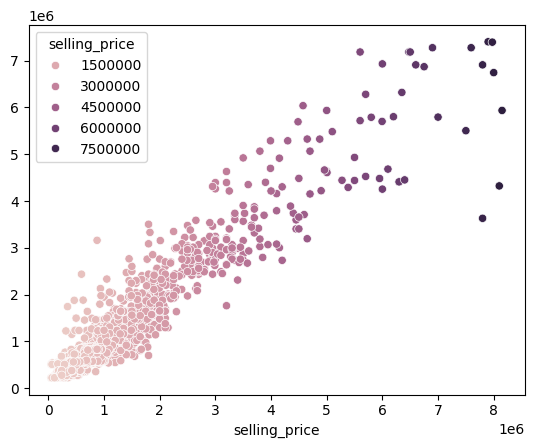